# Иерархический CatBoost с внешними признаками

In [1]:
import os
import sys
import time
import warnings

import matplotlib.pyplot as plt
import pandas as pd

sys.path.append("..")
from src.models.catboost_adapter_for_hc import CatBoostHierarchicalAdapter
from src.models.hierarchical_pipeline import HierarchicalForecaster
from src.utils.metrics import nwrmsle

In [2]:
warnings.filterwarnings("ignore")

# Подготовка данных

In [3]:
RAW_DATA_DIR = r"..\data\raw_data"
PREP_DATA_DIR = r"..\data\prepared_data"

In [4]:
train = pd.read_parquet(os.path.join(PREP_DATA_DIR, "train_filled_last3m.parquet"))
items = pd.read_csv(os.path.join(RAW_DATA_DIR, "items.csv"))
stores = pd.read_csv(os.path.join(RAW_DATA_DIR, "stores.csv"))

In [5]:
# Внешние данные
oil = pd.read_csv(os.path.join(RAW_DATA_DIR, "oil.csv"), parse_dates=["date"])
transactions = pd.read_csv(
    os.path.join(RAW_DATA_DIR, "transactions.csv"), parse_dates=["date"]
)

In [6]:
train = train[train["date"] >= "2017-05-10"]
oil = oil[oil["date"] >= "2017-05-10"]
transactions = transactions[transactions["date"] >= "2017-05-10"]

In [7]:
print(f"train: {train.shape}, период: {train['date'].min()} -> {train['date'].max()}")
print(f"items: {items.shape}, stores: {stores.shape}")

train: (15170556, 5), период: 2017-05-10 00:00:00 -> 2017-08-14 00:00:00
items: (4100, 4), stores: (54, 5)


In [8]:
# Подготавливаем веса для метрики
item_weights = items.set_index("item_nbr")["perishable"].to_dict()
item_weights = {k: 1.25 if v == 1 else 1.0 for k, v in item_weights.items()}

# Разделяем на train/val
train_end_date = pd.Timestamp("2017-07-29")
val_end_date = pd.Timestamp("2017-08-14")

train_data = train[train["date"] <= train_end_date].copy()
val_data = train[
    (train["date"] > train_end_date) & (train["date"] <= val_end_date)
].copy()

# Добавляем веса в валидацию
val_data["weight"] = val_data["item_nbr"].map(item_weights).fillna(1.0)

In [9]:
def prepare_external_features(train_data, val_data, stores, items):
    """
    Подготавливает внешние признаки с использованием pivot для транзакций.
    """
    external = {}

    #  Нефть
    oil_features = oil.copy()
    oil_features.columns = ["date", "oil_price"]
    oil_features["oil_price"] = (
        oil_features["oil_price"].fillna(method="ffill").fillna(method="bfill")
    )

    # Если все еще есть пропуски, заполняем средним
    if oil_features["oil_price"].isna().any():
        oil_features["oil_price"] = oil_features["oil_price"].fillna(
            oil_features["oil_price"].mean()
        )

    oil_features["oil_price_lag1"] = (
        oil_features["oil_price"].shift(1).fillna(method="bfill")
    )
    oil_features["oil_price_lag7"] = (
        oil_features["oil_price"].shift(7).fillna(method="bfill")
    )
    oil_features["oil_price_change"] = oil_features["oil_price"].pct_change().fillna(0)

    external["oil"] = oil_features

    # Транзакции
    trans_with_cluster = transactions.merge(
        stores[["store_nbr", "cluster"]], on="store_nbr", how="left"
    )

    # Создаем полный диапазон дат
    all_dates = pd.date_range(
        start=min(train_data["date"].min(), val_data["date"].min()),
        end=max(train_data["date"].max(), val_data["date"].max()),
        freq="D",
    )

    # Получаем все кластеры
    all_clusters = stores["cluster"].unique()

    # Создаем полную сетку
    full_grid = pd.MultiIndex.from_product(
        [all_dates, all_clusters], names=["date", "cluster"]
    ).to_frame(index=False)

    # Агрегируем транзакции
    cluster_trans = (
        trans_with_cluster.groupby(["date", "cluster"])["transactions"]
        .sum()
        .reset_index()
    )

    # Мерджим с полной сеткой
    cluster_trans = full_grid.merge(cluster_trans, on=["date", "cluster"], how="left")

    # Заполняем пропуски для каждого кластера
    for cluster in all_clusters:
        mask = cluster_trans["cluster"] == cluster
        cluster_trans.loc[mask, "transactions"] = (
            cluster_trans.loc[mask, "transactions"]
            .fillna(method="ffill")
            .fillna(method="bfill")
        )

    # Если остались пропуски, заполняем средним по всем транзакциям
    if cluster_trans["transactions"].isna().any():
        cluster_trans["transactions"] = cluster_trans["transactions"].fillna(
            cluster_trans["transactions"].mean()
        )

    external["transactions"] = cluster_trans

    return external

In [10]:
external_data = prepare_external_features(train_data, val_data, stores, items)
print("Внешние признаки подготовлены:")
for key in external_data:
    print(f"  {key}: {external_data[key].shape}")

Внешние признаки подготовлены:
  oil: (82, 5)
  transactions: (1649, 3)


# Обучение и прогнозирование

In [11]:
def create_catboost_adapter(
    horizon: int = 16, history: int = 90, use_external: bool = True
):
    """Фабрика для создания адаптеров CatBoost"""
    return CatBoostHierarchicalAdapter(
        model_params={
            "iterations": 1000,
            "learning_rate": 0.05,
            "depth": 6,
            "loss_function": "RMSE",
            "random_seed": 42,
            "verbose": False,
            "early_stopping_rounds": 50,
        },
        horizon=horizon,
        history=history,
        use_external_features=use_external,
    )

In [12]:
# Параметры
horizon = (val_data["date"].max() - val_data["date"].min()).days + 1
print(f"Горизонт прогноза: {horizon} дней")

Горизонт прогноза: 16 дней


In [13]:
def create_catboost_for_level(level_name=None):
    """Создает адаптер CatBoost с параметрами, специфичными для уровня иерархии"""
    adapter = CatBoostHierarchicalAdapter(
        model_params={
            "iterations": 200,
            "learning_rate": 0.01,
            "depth": 5,
            "loss_function": "RMSE",
            "random_seed": 42,
            "verbose": False,
            "early_stopping_rounds": 10,
            "task_type": "GPU",
        },
        horizon=horizon,
        history=60,
        use_external_features=True,
    )
    if level_name:
        adapter.set_level_name(level_name)
    return adapter

In [14]:
# Создаем иерархический прогнозист
hier_forecaster = HierarchicalForecaster(stores, items)

In [15]:
# Создаем иерархию
aggregated_series = hier_forecaster.create_hierarchy(train_data)

Создание иерархии...
  Всего уникальных товаров: 3938
  Всего уникальных магазинов: 54
  Средние продажи total: 5.52
Пропорции вычислены:
  Средние продажи (total): 5.48
  Уникальных store_proportions: 54
  Уникальных item_proportions: 54365
  Total: 81 дней
  By cluster: 17 кластеров
  By cluster+family: 546 групп


In [16]:
start_time = time.time()

# Уровень total
print("--- Уровень Total ---")
total_series = aggregated_series["total"].rename(columns={"total_sales": "value"})
total_val = total_series[total_series["date"] >= train_end_date - pd.Timedelta(days=60)]

total_model = create_catboost_for_level("total")
total_model.fit(
    train_data=total_series[total_series["date"] <= train_end_date],
    val_data=total_val,
    external_data=external_data,
)
hier_forecaster.trained_models["total"] = total_model

# Уровень cluster
print("\n--- Уровень Clusters ---")
cluster_models = {}
clusters_list = list(aggregated_series["by_cluster"]["cluster"].unique())
for idx, cluster in enumerate(clusters_list):
    print(f"  Кластер {cluster} ({idx+1}/{len(clusters_list)})")
    cluster_data = (
        aggregated_series["by_cluster"][
            aggregated_series["by_cluster"]["cluster"] == cluster
        ]
        .rename(columns={"unit_sales": "value"})
        .sort_values("date")
    )

    if len(cluster_data) < 30:
        print(f"    Пропускаем (мало данных: {len(cluster_data)} дней)")
        continue

    cluster_val = cluster_data[
        cluster_data["date"] >= train_end_date - pd.Timedelta(days=60)
    ]

    cluster_model = create_catboost_for_level(f"cluster_{cluster}")
    cluster_model.fit(
        train_data=cluster_data[cluster_data["date"] <= train_end_date],
        val_data=cluster_val,
        external_data=external_data,
    )
    cluster_models[cluster] = cluster_model

hier_forecaster.trained_models["clusters"] = cluster_models

# Уровень cluster+family
print("\n--- Уровень Cluster+Family ---")
cf_models = {}
cf_groups = list(aggregated_series["by_cluster_family"].groupby(["cluster", "family"]))
total_groups = len(cf_groups)

for idx, ((cluster, family), group) in enumerate(cf_groups):
    if idx % 50 == 0:
        print(f"  Прогресс: {idx}/{total_groups}")

    cf_data = group.rename(columns={"unit_sales": "value"}).sort_values("date")

    if len(cf_data) < 30:
        continue

    cf_val = cf_data[cf_data["date"] >= train_end_date - pd.Timedelta(days=60)]

    cf_model = create_catboost_for_level(f"cluster_{cluster}_family_{family}")
    cf_model.fit(
        train_data=cf_data[cf_data["date"] <= train_end_date],
        val_data=cf_val,
        external_data=external_data,
    )
    cf_models[(cluster, family)] = cf_model

hier_forecaster.trained_models["cluster_family"] = cf_models

elapsed = time.time() - start_time
print(f"\nОбучение CatBoost завершено за {elapsed:.1f} секунд")
print(
    f"Обучено моделей: Total: 1, Clusters: {len(cluster_models)}, Cluster+Family: {len(cf_models)}"
)

--- Уровень Total ---
    Обучение CatBoost для total
    ✅ Обучение завершено. Лучшая итерация: 199

--- Уровень Clusters ---
  Кластер 1 (1/17)
    Обучение CatBoost для cluster_1
    ✅ Обучение завершено. Лучшая итерация: 199
  Кластер 2 (2/17)
    Обучение CatBoost для cluster_2
    ✅ Обучение завершено. Лучшая итерация: 199
  Кластер 3 (3/17)
    Обучение CatBoost для cluster_3
    ✅ Обучение завершено. Лучшая итерация: 199
  Кластер 4 (4/17)
    Обучение CatBoost для cluster_4
    ✅ Обучение завершено. Лучшая итерация: 199
  Кластер 5 (5/17)
    Обучение CatBoost для cluster_5
    ✅ Обучение завершено. Лучшая итерация: 199
  Кластер 6 (6/17)
    Обучение CatBoost для cluster_6
    ✅ Обучение завершено. Лучшая итерация: 199
  Кластер 7 (7/17)
    Обучение CatBoost для cluster_7
    ✅ Обучение завершено. Лучшая итерация: 199
  Кластер 8 (8/17)
    Обучение CatBoost для cluster_8
    ✅ Обучение завершено. Лучшая итерация: 199
  Кластер 9 (9/17)
    Обучение CatBoost для cluster_9
  

In [17]:
def predict_catboost_aggregated(forecaster, horizon, start_date, external_data=None):
    """Получает прогнозы от всех обученных CatBoost моделей"""

    forecasts = {
        "total": None,
        "clusters": {},
        "cluster_family": {},
        "dates": pd.date_range(start=start_date, periods=horizon),
    }

    # Total level
    total_model = forecaster.trained_models["total"]
    total_last_data = (
        forecaster.aggregated_series["total"]
        .rename(columns={"total_sales": "value"})
        .tail(60)
    )
    forecasts["total"] = total_model.predict(horizon, total_last_data, external_data)

    # Cluster level
    for cluster, model in forecaster.trained_models["clusters"].items():
        cluster_last_data = (
            forecaster.aggregated_series["by_cluster"][
                forecaster.aggregated_series["by_cluster"]["cluster"] == cluster
            ]
            .rename(columns={"unit_sales": "value"})
            .tail(60)
        )
        forecasts["clusters"][cluster] = model.predict(
            horizon, cluster_last_data, external_data
        )

    # Cluster+Family level
    for (cluster, family), model in forecaster.trained_models["cluster_family"].items():
        cf_last_data = (
            forecaster.aggregated_series["by_cluster_family"][
                (
                    forecaster.aggregated_series["by_cluster_family"]["cluster"]
                    == cluster
                )
                & (
                    forecaster.aggregated_series["by_cluster_family"]["family"]
                    == family
                )
            ]
            .rename(columns={"unit_sales": "value"})
            .tail(60)
        )
        forecasts["cluster_family"][(cluster, family)] = model.predict(
            horizon, cf_last_data, external_data
        )

    return forecasts

In [18]:
start_date = val_data["date"].min()
forecasts = predict_catboost_aggregated(
    hier_forecaster, horizon, start_date, external_data=external_data
)

    Прогнозирование для total, признаков: 26
    Прогнозирование для cluster_1, признаков: 30
    Прогнозирование для cluster_2, признаков: 30
    Прогнозирование для cluster_3, признаков: 30
    Прогнозирование для cluster_4, признаков: 30
    Прогнозирование для cluster_5, признаков: 30
    Прогнозирование для cluster_6, признаков: 30
    Прогнозирование для cluster_7, признаков: 30
    Прогнозирование для cluster_8, признаков: 30
    Прогнозирование для cluster_9, признаков: 30
    Прогнозирование для cluster_10, признаков: 30
    Прогнозирование для cluster_11, признаков: 30
    Прогнозирование для cluster_12, признаков: 30
    Прогнозирование для cluster_13, признаков: 30
    Прогнозирование для cluster_14, признаков: 30
    Прогнозирование для cluster_15, признаков: 30
    Прогнозирование для cluster_16, признаков: 30
    Прогнозирование для cluster_17, признаков: 30
    Прогнозирование для cluster_1_family_AUTOMOTIVE, признаков: 31
    Прогнозирование для cluster_1_family_BABY C

In [19]:
# Дизагрегируем прогнозы
start_time = time.time()

val_pairs = list(val_data.groupby(["store_nbr", "item_nbr"]).groups.keys())
print(f"Всего уникальных пар в валидации: {len(val_pairs)}")

val_predictions = hier_forecaster.disaggregate_to_store_item(
    forecasts=forecasts, test_pairs=val_pairs
)

elapsed = time.time() - start_time
print(f"Дизагрегация завершена за {elapsed:.1f} секунд")
print(f"Получено прогнозов: {len(val_predictions)}")

Всего уникальных пар в валидации: 158636
Дизагрегация прогнозов до уровня магазин-товар...
  Средние продажи (total): 5.48
  Форма total прогноза: (16,)
  Прогресс: 0.0% (0/158636)
  Прогресс: 10.0% (15863/158636)
  Прогресс: 20.0% (31726/158636)
  Прогресс: 30.0% (47589/158636)
  Прогресс: 40.0% (63452/158636)
  Прогресс: 50.0% (79315/158636)
  Прогресс: 60.0% (95178/158636)
  Прогресс: 70.0% (111041/158636)
  Прогресс: 80.0% (126904/158636)
  Прогресс: 90.0% (142767/158636)
  Прогресс: 100.0% (158630/158636)
  Дизагрегация завершена. Всего прогнозов: 2538176
Дизагрегация завершена за 268.5 секунд
Получено прогнозов: 2538176


In [20]:
val_with_pred = val_data.merge(
    val_predictions[["store_nbr", "item_nbr", "date", "predicted"]],
    on=["store_nbr", "item_nbr", "date"],
    how="left",
)

missing_pred = val_with_pred["predicted"].isna().sum()
if missing_pred > 0:
    print(f"Предупреждение: {missing_pred} записей без прогноза")
    val_with_pred["predicted"] = val_with_pred["predicted"].fillna(0)

# Результаты

In [21]:
# Считаем метрику
cb_score = nwrmsle(
    val_with_pred["unit_sales"].values,
    val_with_pred["predicted"].values,
    val_with_pred["weight"].values,
)
print(f"Иерархический CatBoost NWRMSLE: {cb_score:.6f}")

Иерархический CatBoost NWRMSLE: 1.273691


In [22]:
val_with_pred["cluster"] = val_with_pred["store_nbr"].map(
    stores.set_index("store_nbr")["cluster"]
)
val_with_pred["family"] = val_with_pred["item_nbr"].map(
    items.set_index("item_nbr")["family"]
)
val_with_pred["perishable"] = val_with_pred["item_nbr"].map(
    items.set_index("item_nbr")["perishable"]
)

# По кластерам
print("Ошибка по кластерам магазинов:")
cluster_errors = (
    val_with_pred.groupby("cluster")
    .apply(
        lambda x: nwrmsle(
            x["unit_sales"].values, x["predicted"].values, x["weight"].values
        )
    )
    .sort_values(ascending=False)
)
for cluster, error in cluster_errors.head(10).items():
    print(f"  Кластер {cluster}: {error:.6f}")

# По семействам
print("\nОшибка по семействам товаров (топ-5 худших):")
family_errors = (
    val_with_pred.groupby("family")
    .apply(
        lambda x: nwrmsle(
            x["unit_sales"].values, x["predicted"].values, x["weight"].values
        )
    )
    .sort_values(ascending=False)
    .head(5)
)
for family, error in family_errors.items():
    print(f"  {family}: {error:.6f}")

Ошибка по кластерам магазинов:
  Кластер 6: 1.427398
  Кластер 14: 1.410374
  Кластер 5: 1.367897
  Кластер 10: 1.336214
  Кластер 11: 1.317786
  Кластер 8: 1.275164
  Кластер 1: 1.261691
  Кластер 13: 1.251402
  Кластер 3: 1.232331
  Кластер 15: 1.209765

Ошибка по семействам товаров (топ-5 худших):
  PRODUCE: 1.700556
  POULTRY: 1.573724
  MEATS: 1.492594
  BEVERAGES: 1.414833
  BREAD/BAKERY: 1.394153


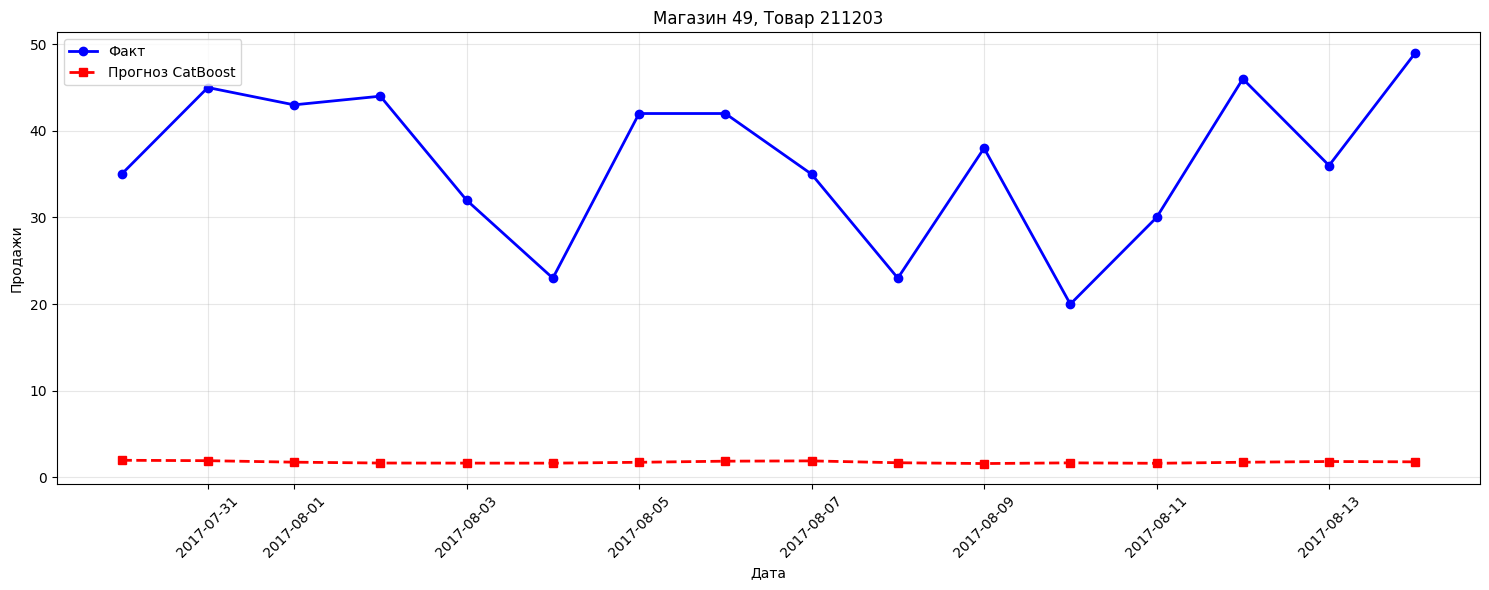

In [23]:
# Выберем случайную пару для визуализации
example_store = 49
example_item = 211203
example_data = val_with_pred[
    (val_with_pred["store_nbr"] == example_store)
    & (val_with_pred["item_nbr"] == example_item)
].sort_values("date")

if len(example_data) > 0:
    plt.figure(figsize=(15, 6))
    plt.plot(
        example_data["date"],
        example_data["unit_sales"],
        "b-",
        label="Факт",
        linewidth=2,
        marker="o",
    )
    plt.plot(
        example_data["date"],
        example_data["predicted"],
        "r--",
        label="Прогноз CatBoost",
        linewidth=2,
        marker="s",
    )
    plt.title(f"Магазин {example_store}, Товар {example_item}")
    plt.xlabel("Дата")
    plt.ylabel("Продажи")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Ожидаемый результат - проблема с масштабом для той же самой пары, что в случае с AutoETS осталась.

Однака важно заметить, что скор заметно улучшился: **1.273691**.

Повышение количества итераций улучшает скор, но затрачиваемое время увеличивается очень значительно.  
Из детализации ошибок может сделать вывод, что чаще всего модель ошибается на наиболее популярных продуктах - то, что может покупаться в совершенно разных количествах, при том как дискретное, так и непрерывное (дробное) значение единиц.
Но скор улучшился и в решении также были использованы внешние признаки.